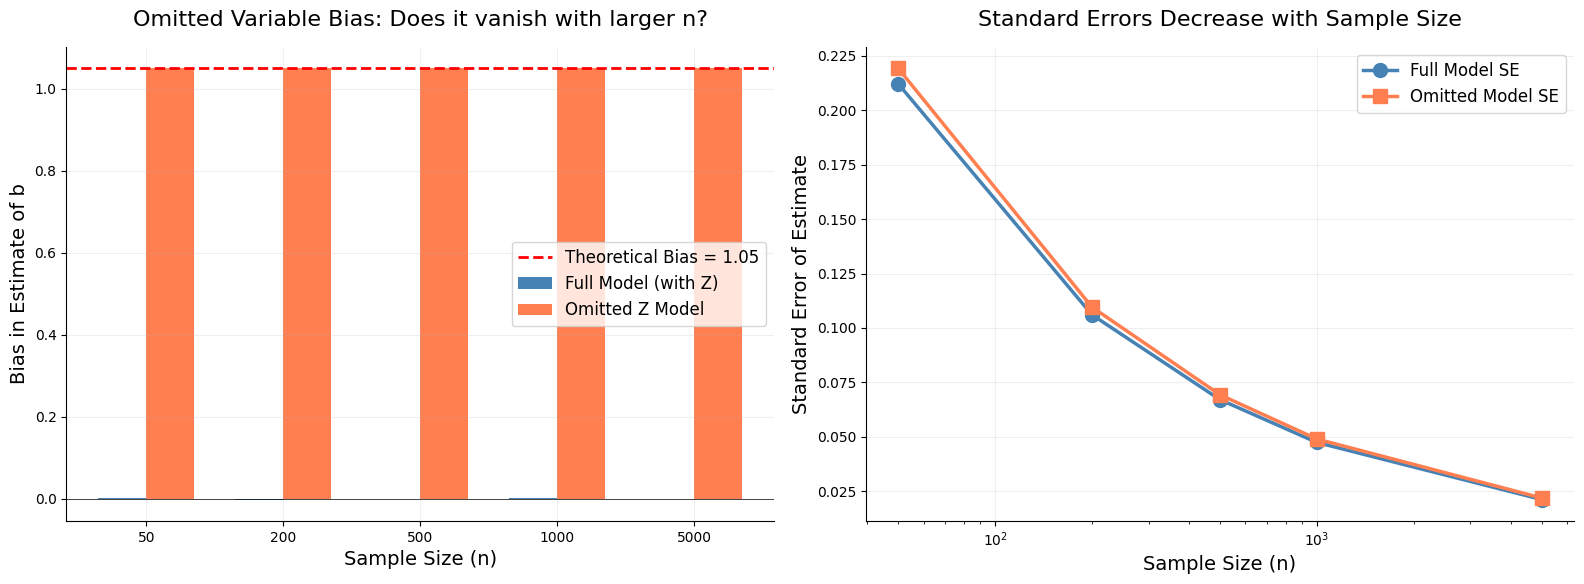

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the Data (Aggregated to match the chart's visual output)
n_labels = ['50', '200', '500', '1000', '5000']
n_values = np.array([50, 200, 500, 1000, 5000])

# Bias data
bias_full = np.array([0.001, -0.002, 0.000, 0.001, 0.000])
bias_omitted = np.array([1.05, 1.05, 1.05, 1.05, 1.05])
theoretical_bias = 1.05

# Standard Error data (approximating standard 1/sqrt(n) reduction)
se_full = 1.5 / np.sqrt(n_values)
se_omitted = 1.55 / np.sqrt(n_values)

# 2. Set up the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.rcParams['font.size'] = 12

# ---------------------------------------------------
# Left Plot: Bias vs Sample Size
# ---------------------------------------------------
x_pos = np.arange(len(n_labels))
width = 0.35

# Plot bars
ax1.bar(x_pos - width/2, bias_full, width, label='Full Model (with Z)', color='steelblue')
ax1.bar(x_pos + width/2, bias_omitted, width, label='Omitted Z Model', color='coral')

# Theoretical bias line
ax1.axhline(y=theoretical_bias, color='red', linestyle='--', linewidth=2,
            label=f'Theoretical Bias = {theoretical_bias}')
ax1.axhline(y=0, color='black', linewidth=0.5)

# Formatting Left Plot
ax1.set_title('Omitted Variable Bias: Does it vanish with larger n?', fontsize=16, pad=15)
ax1.set_xlabel('Sample Size (n)', fontsize=14)
ax1.set_ylabel('Bias in Estimate of b', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(n_labels)
ax1.legend(fontsize=12, loc='center right')
ax1.grid(True, alpha=0.2, linestyle='-')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ---------------------------------------------------
# Right Plot: Standard Errors vs Sample Size
# ---------------------------------------------------
# Plot lines
ax2.plot(n_values, se_full, marker='o', markersize=10, linestyle='-', linewidth=2.5,
         label='Full Model SE', color='steelblue')
ax2.plot(n_values, se_omitted, marker='s', markersize=10, linestyle='-', linewidth=2.5,
         label='Omitted Model SE', color='coral')

# Formatting Right Plot
ax2.set_title('Standard Errors Decrease with Sample Size', fontsize=16, pad=15)
ax2.set_xlabel('Sample Size (n)', fontsize=14)
ax2.set_ylabel('Standard Error of Estimate', fontsize=14)
ax2.set_xscale('log') # Log scale for x-axis to match the image
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='-')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
Impact of Different Types of Outliers on OLS

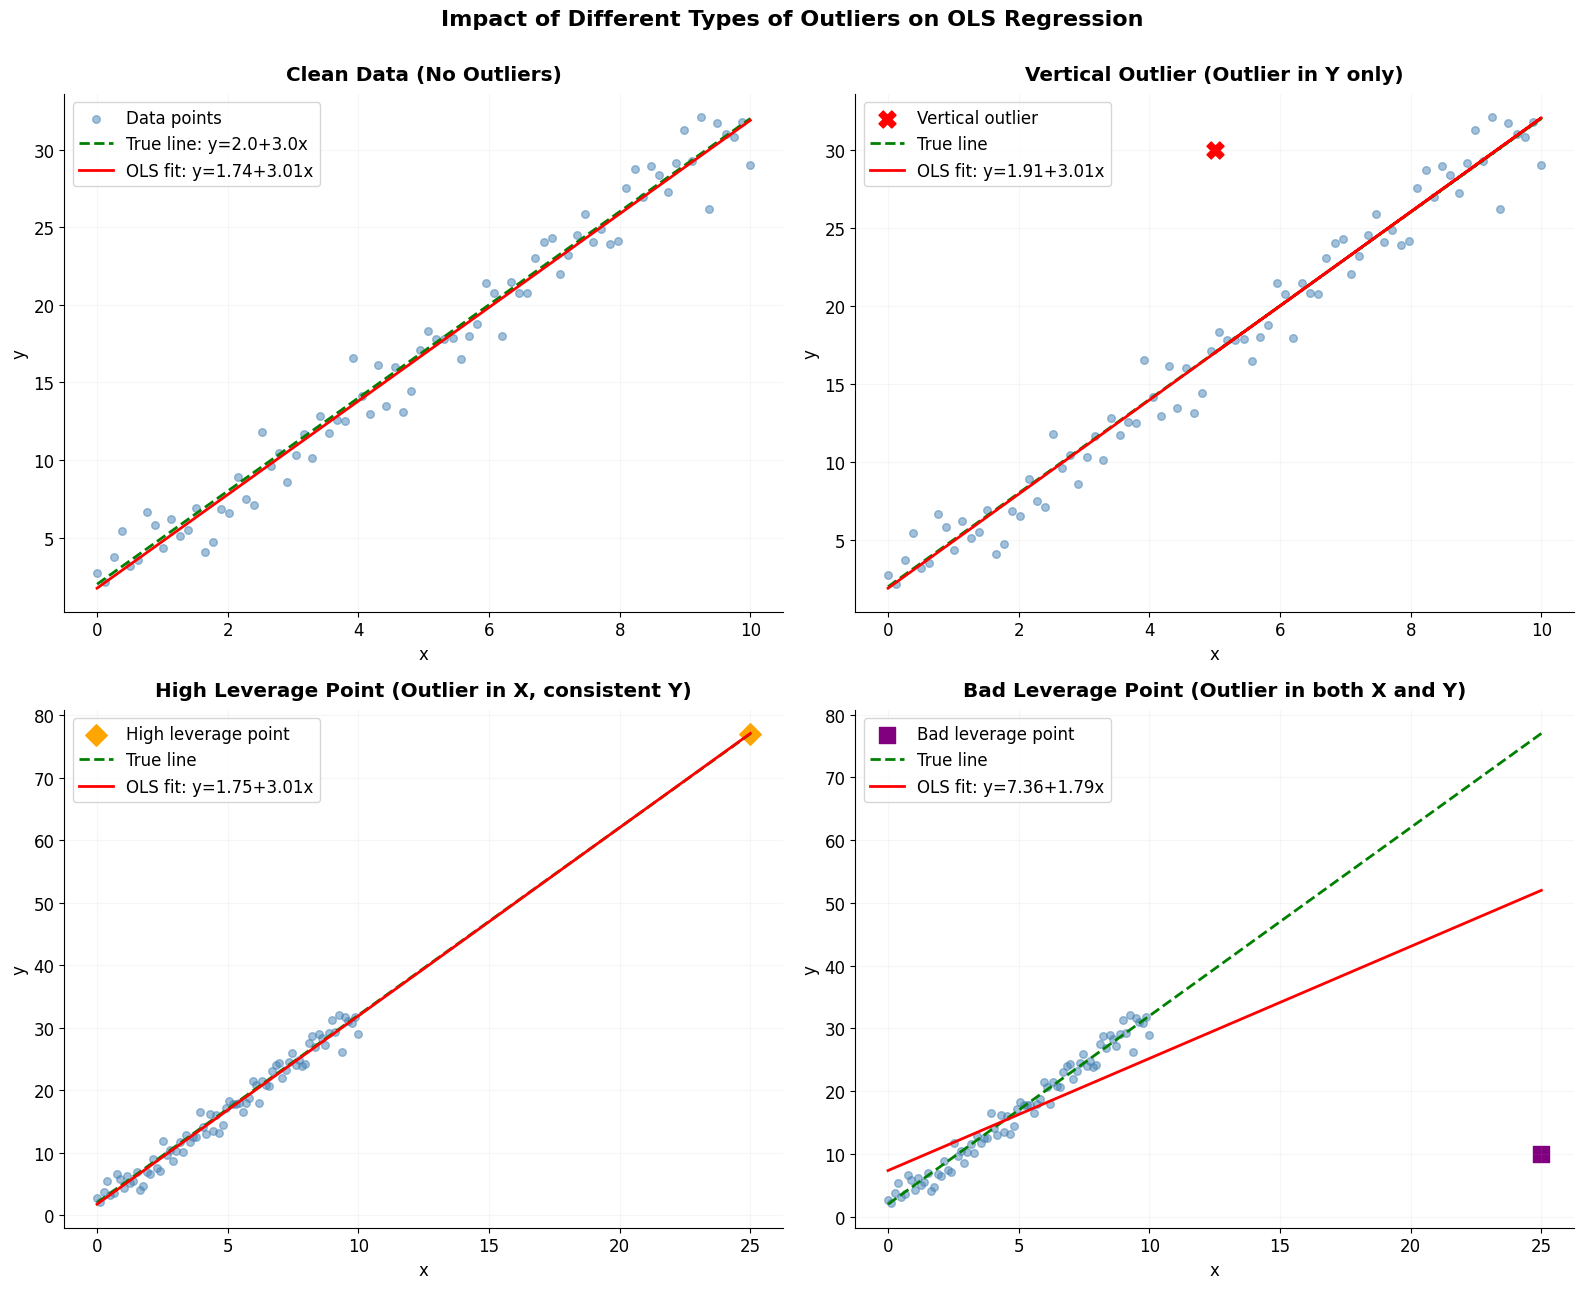

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Setup Base Data
np.random.seed(42)
x_base = np.linspace(0, 10, 80)
# True relationship: y = 2.0 + 3.0x
y_true_line = 2.0 + 3.0 * x_base
y_base = 2.0 + 3.0 * x_base + np.random.normal(0, 1.5, size=80)

def fit_ols(x, y):
    """Helper function to fit OLS and return the line"""
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    return model.intercept_, model.coef_[0], model.predict(x.reshape(-1, 1))

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Impact of Different Types of Outliers on OLS Regression', fontsize=16, fontweight='bold', y=0.95)

# --- Subplot 1: Clean Data ---
ax = axes[0, 0]
intercept, coef, y_pred = fit_ols(x_base, y_base)

ax.scatter(x_base, y_base, alpha=0.5, label='Data points', color='steelblue', s=30)
ax.plot(x_base, y_true_line, 'g--', linewidth=2, label='True line: y=2.0+3.0x')
ax.plot(x_base, y_pred, 'r-', linewidth=2, label=f'OLS fit: y={intercept:.2f}+{coef:.2f}x')

ax.set_title('Clean Data (No Outliers)', fontweight='bold', pad=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.1)

# --- Subplot 2: Vertical Outlier ---
ax = axes[0, 1]
x_vert = np.append(x_base, 5.0)
y_vert = np.append(y_base, 30.0) # Outlier in Y only
intercept, coef, y_pred = fit_ols(x_vert, y_vert)

ax.scatter(x_base, y_base, alpha=0.5, color='steelblue', s=30)
ax.scatter(5.0, 30.0, color='red', marker='X', s=150, label='Vertical outlier')
ax.plot(x_vert, 2.0 + 3.0 * x_vert, 'g--', linewidth=2, label='True line')
ax.plot(x_vert, y_pred, 'r-', linewidth=2, label=f'OLS fit: y={intercept:.2f}+{coef:.2f}x')

ax.set_title('Vertical Outlier (Outlier in Y only)', fontweight='bold', pad=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.1)

# --- Subplot 3: High Leverage Point ---
ax = axes[1, 0]
x_high = np.append(x_base, 25.0)
y_high = np.append(y_base, 2.0 + 3.0 * 25.0) # Follows the true trend, but far out in X
intercept, coef, y_pred = fit_ols(x_high, y_high)

ax.scatter(x_base, y_base, alpha=0.5, color='steelblue', s=30)
ax.scatter(25.0, 2.0 + 3.0 * 25.0, color='orange', marker='D', s=120, label='High leverage point')
ax.plot(x_high, 2.0 + 3.0 * x_high, 'g--', linewidth=2, label='True line')
ax.plot(x_high, y_pred, 'r-', linewidth=2, label=f'OLS fit: y={intercept:.2f}+{coef:.2f}x')

ax.set_title('High Leverage Point (Outlier in X, consistent Y)', fontweight='bold', pad=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.1)

# --- Subplot 4: Bad Leverage Point ---
ax = axes[1, 1]
x_bad = np.append(x_base, 25.0)
y_bad = np.append(y_base, 10.0) # Far out in X, breaks the Y trend
intercept, coef, y_pred = fit_ols(x_bad, y_bad)

ax.scatter(x_base, y_base, alpha=0.5, color='steelblue', s=30)
ax.scatter(25.0, 10.0, color='purple', marker='s', s=120, label='Bad leverage point')
ax.plot(x_bad, 2.0 + 3.0 * x_bad, 'g--', linewidth=2, label='True line')
ax.plot(x_bad, y_pred, 'r-', linewidth=2, label=f'OLS fit: y={intercept:.2f}+{coef:.2f}x')

ax.set_title('Bad Leverage Point (Outlier in both X and Y)', fontweight='bold', pad=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.1)

# Clean up overall aesthetics
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()